### Importing modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Loading coverage data

In [2]:
file_path = '../data/genotypes/geno5.counts'
coverage_df = pd.read_table(file_path).iloc[:,:-1].T
coverage_df

,0,1,2,3,4,5,6,7,8,9,...,1696,1697,1698,1699,1700,1701,1702,1703,1704,1705
ind0TotDepth,20,5,11,36,0,12,9,16,27,35,...,60,79,37,12,10,31,31,38,13,40
ind1TotDepth,18,9,10,47,0,10,10,11,29,20,...,50,79,44,12,18,56,56,36,21,34
ind2TotDepth,18,8,10,44,9,6,13,19,22,20,...,45,80,38,11,21,36,37,38,8,28
ind3TotDepth,52,36,30,48,27,44,33,46,46,50,...,47,60,63,30,49,9,9,28,21,47
ind4TotDepth,41,31,21,59,29,22,23,22,30,48,...,87,114,66,39,52,31,31,36,41,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ind239TotDepth,19,10,5,27,0,15,13,19,13,33,...,60,57,40,8,5,53,53,12,13,23
ind240TotDepth,59,16,32,60,10,46,22,52,45,85,...,87,75,56,0,0,64,64,23,22,39
ind241TotDepth,23,0,0,40,5,14,14,24,10,26,...,47,64,46,0,7,32,32,23,7,18
ind242TotDepth,51,30,31,55,62,29,26,48,90,45,...,68,125,60,36,68,37,37,50,25,74


### SNP level summary

In [3]:
depth_summary = coverage_df.describe().T
depth_summary

,count,mean,std,min,25%,50%,75%,max
0,244.0,31.422131,16.426858,0.0,19.00,28.0,43.00,77.0
1,244.0,14.479508,11.638396,0.0,6.00,11.0,22.00,55.0
2,244.0,14.372951,11.520435,0.0,6.00,11.0,22.00,45.0
3,244.0,45.073770,20.788438,0.0,32.00,43.0,56.00,126.0
4,244.0,16.827869,15.622972,0.0,6.00,11.0,26.00,66.0
...,...,...,...,...,...,...,...,...
1701,244.0,41.418033,17.153310,9.0,29.75,39.5,50.25,100.0
1702,244.0,41.352459,17.195282,9.0,29.75,39.5,50.25,100.0
1703,244.0,24.352459,18.008650,0.0,9.00,23.0,37.00,76.0
1704,244.0,17.889344,13.397379,0.0,8.00,17.0,27.00,61.0


### Global average coverage depth

In [4]:
coverage_df.values.mean()

33.71211538831126

In [5]:
coverage_df.values.std()

23.731585441538193

### Coverage distibution among SNPs

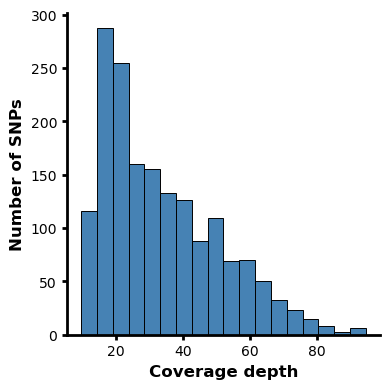

In [9]:
fig, ax1 = plt.subplots(figsize=(4, 4))

# Histogram with outlined bars and pleasant color
ax1.hist(depth_summary['mean'], bins=18,
         color='steelblue', edgecolor='black', linewidth=0.7)

# Styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_linewidth(2)
ax1.tick_params(axis='both', width=2)
# Labels
ax1.set_xlabel('Coverage depth', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of SNPs', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("../figures/snp_coverage_distribution.pdf", bbox_inches='tight')
plt.show()


### Coverage distribution among samples

In [8]:
sample_cov_dist = coverage_df.T.describe().T
sample_cov_dist

,count,mean,std,min,25%,50%,75%,max
ind0TotDepth,1706.0,33.445487,23.127156,0.0,14.0,28.0,48.00,138.0
ind1TotDepth,1706.0,33.230950,22.516765,0.0,14.0,29.0,49.00,148.0
ind2TotDepth,1706.0,29.723329,21.733219,0.0,12.0,23.5,43.00,127.0
ind3TotDepth,1706.0,31.000000,17.625528,0.0,18.0,29.0,42.00,121.0
ind4TotDepth,1706.0,48.882181,19.843454,0.0,35.0,48.0,61.00,142.0
...,...,...,...,...,...,...,...,...
ind239TotDepth,1706.0,24.055100,17.219590,0.0,11.0,19.0,34.75,115.0
ind240TotDepth,1706.0,35.080305,24.157499,0.0,15.0,31.0,51.00,145.0
ind241TotDepth,1706.0,23.063306,18.800311,0.0,9.0,18.0,34.00,132.0
ind242TotDepth,1706.0,43.260258,21.852054,0.0,26.0,42.0,57.00,165.0


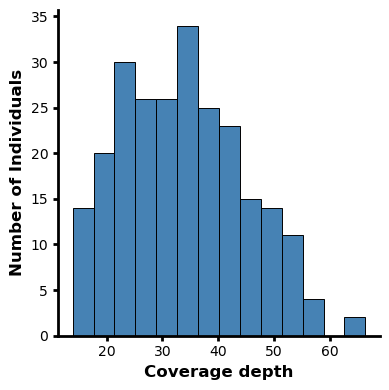

In [12]:
fig, ax1 = plt.subplots(figsize=(4, 4))

# Histogram with outlined bars and pleasant color
ax1.hist(sample_cov_dist['mean'], bins=14,
         color='steelblue', edgecolor='black', linewidth=0.7)

# Styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_linewidth(2)
ax1.tick_params(axis='both', width=2)
# Labels
ax1.set_xlabel('Coverage depth', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Individuals', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("../figures/Ind_coverage_distribution.pdf", bbox_inches='tight')
plt.show()

### Genotype call rate

In [9]:
df_by_snp = pd.read_table('../data/genotypes/geno5.geno', header = None)
df_by_snp = df_by_snp.drop([0, 1, len(df_by_snp.columns)-1], axis=1)
df_by_snp.index = range(len(df_by_snp))
df_by_snp

,2,3,4,5,6,7,8,9,10,11,...,236,237,238,239,240,241,242,243,244,245
0,TT,TT,TT,TT,TT,TT,TT,TT,TT,TT,...,TT,TT,TT,TT,TT,TT,TC,TT,TT,TT
1,CC,AA,AA,AC,AA,AA,AA,AA,AA,AA,...,AA,NN,AA,AA,AA,AA,AC,NN,AC,AC
2,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA,...,AA,NN,AG,AA,NN,AA,AA,NN,AA,AA
3,AA,TT,TT,TT,TT,TT,TT,AA,TA,AA,...,TT,AA,TT,TA,TA,AA,TT,TT,TT,TT
4,NN,NN,GG,GG,GG,AA,AA,GG,GG,NN,...,NN,GG,NN,GG,AA,NN,GA,GG,GA,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1701,CC,CC,CC,CC,CC,CC,CC,CT,CC,CC,...,CC,CC,CC,CC,CC,CC,CC,CC,CC,CC
1702,CC,CT,CC,CC,CC,CC,CC,CC,CC,CT,...,CC,CC,CC,CC,CC,CC,CT,CC,CC,CC
1703,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA,...,AA,AA,AA,NN,AG,AA,AA,AA,AA,NN
1704,TT,TT,TT,TT,TT,TT,TT,TT,TT,TT,...,TT,TT,TT,TC,NN,TT,TT,TT,TT,NN


In [10]:
def count_not_missing(row):
    return (row != 'NN').sum()

In [11]:
df_by_snp['count_not_missing'] = df_by_snp.apply(lambda row: count_not_missing(row), axis=1)
df_by_snp['geno_call_rate'] = df_by_snp['count_not_missing'] / (len(df_by_snp.columns)-1) * 100
df_by_snp

,2,3,4,5,6,7,8,9,10,11,...,238,239,240,241,242,243,244,245,count_not_missing,geno_call_rate
0,TT,TT,TT,TT,TT,TT,TT,TT,TT,TT,...,TT,TT,TT,TT,TC,TT,TT,TT,242,99.180328
1,CC,AA,AA,AC,AA,AA,AA,AA,AA,AA,...,AA,AA,AA,AA,AC,NN,AC,AC,209,85.655738
2,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA,...,AG,AA,NN,AA,AA,NN,AA,AA,203,83.196721
3,AA,TT,TT,TT,TT,TT,TT,AA,TA,AA,...,TT,TA,TA,AA,TT,TT,TT,TT,241,98.770492
4,NN,NN,GG,GG,GG,AA,AA,GG,GG,NN,...,NN,GG,AA,NN,GA,GG,GA,AA,203,83.196721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1701,CC,CC,CC,CC,CC,CC,CC,CT,CC,CC,...,CC,CC,CC,CC,CC,CC,CC,CC,244,100.000000
1702,CC,CT,CC,CC,CC,CC,CC,CC,CC,CT,...,CC,CC,CC,CC,CT,CC,CC,CC,244,100.000000
1703,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA,...,AA,NN,AG,AA,AA,AA,AA,NN,206,84.426230
1704,TT,TT,TT,TT,TT,TT,TT,TT,TT,TT,...,TT,TC,NN,TT,TT,TT,TT,NN,203,83.196721


In [12]:
df_by_snp.geno_call_rate.mean()

94.60798916072493

In [13]:
df_by_snp.geno_call_rate.std()

6.209852091944791

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

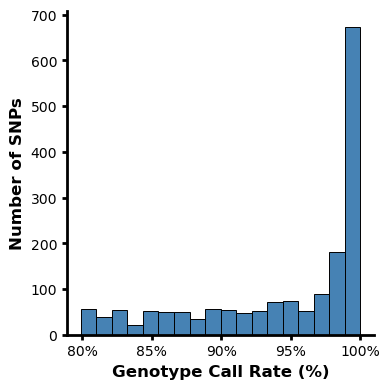

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Ensure vector-editable text in PDF
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

# Percentage formatter for x-axis
percent_formatter = ticker.PercentFormatter(xmax=1.0, decimals=0)

fig, ax1 = plt.subplots(figsize=(4, 4))

# Histogram with outlined bars and pleasant color
ax1.hist(df_by_snp['geno_call_rate'].dropna()/100, bins=18,
         color='steelblue', edgecolor='black', linewidth=0.7)

# Styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_linewidth(2)
ax1.tick_params(axis='both', width=2)

# Apply percentage formatting and limit ticks to 5
ax1.xaxis.set_major_formatter(percent_formatter)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

# Labels
ax1.set_xlabel('Genotype Call Rate (%)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of SNPs', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("../figures/geno_call_rate_distribution.pdf", bbox_inches='tight')
plt.show()


In [15]:
df_by_ind = pd.read_table('../data/genotypes/geno5.geno', header = None)
df_by_ind = df_by_ind.drop([0, 1, len(df_by_ind.columns)-1], axis=1).T
df_by_ind.index = range(len(df_by_ind))
df_by_ind

,0,1,2,3,4,5,6,7,8,9,...,1696,1697,1698,1699,1700,1701,1702,1703,1704,1705
0,TT,CC,AA,AA,NN,AA,CC,CC,GG,CC,...,GA,GG,AA,AA,GG,CC,CC,AA,TT,AA
1,TT,AA,AA,TT,NN,AA,CC,CC,GG,CC,...,GG,GG,AA,AA,GG,CC,CT,AA,TT,AA
2,TT,AA,AA,TT,GG,AA,CC,CC,GG,AA,...,GG,AA,AA,AA,GG,CC,CC,AA,TT,AA
3,TT,AC,AA,TT,GG,AA,CC,CC,GG,AA,...,GG,GG,AA,AA,GG,CC,CC,AA,TT,AA
4,TT,AA,AA,TT,GG,AA,CC,CC,GG,CC,...,GA,GA,AA,AA,GG,CC,CC,AA,TT,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,TT,AA,AA,AA,NN,AA,CC,CC,GG,CC,...,GA,GG,AA,AA,GG,CC,CC,AA,TT,AA
240,TC,AC,AA,TT,GA,AA,CC,CC,GG,CA,...,GA,GG,AA,NN,NN,CC,CT,AA,TT,AT
241,TT,NN,NN,TT,GG,AA,CC,CC,GG,AA,...,GG,GG,AA,NN,GG,CC,CC,AA,TT,AA
242,TT,AC,AA,TT,GA,AA,CC,CC,GA,AA,...,GA,GG,AA,AA,GG,CC,CC,AA,TT,AT


In [16]:
df_by_ind['count_not_missing'] = df_by_ind.apply(lambda row: count_not_missing(row), axis=1)
df_by_ind['count_missing'] = len(df_by_ind.columns) - 1 - df_by_ind['count_not_missing']
df_by_ind['missing_percent'] = df_by_ind['count_missing'] / (len(df_by_ind.columns)-2) * 100
df_by_ind

,0,1,2,3,4,5,6,7,8,9,...,1699,1700,1701,1702,1703,1704,1705,count_not_missing,count_missing,missing_percent
0,TT,CC,AA,AA,NN,AA,CC,CC,GG,CC,...,AA,GG,CC,CC,AA,TT,AA,1676,30,1.758499
1,TT,AA,AA,TT,NN,AA,CC,CC,GG,CC,...,AA,GG,CC,CT,AA,TT,AA,1669,37,2.168816
2,TT,AA,AA,TT,GG,AA,CC,CC,GG,AA,...,AA,GG,CC,CC,AA,TT,AA,1654,52,3.048066
3,TT,AC,AA,TT,GG,AA,CC,CC,GG,AA,...,AA,GG,CC,CC,AA,TT,AA,1657,49,2.872216
4,TT,AA,AA,TT,GG,AA,CC,CC,GG,CC,...,AA,GG,CC,CC,AA,TT,AA,1702,4,0.234467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,TT,AA,AA,AA,NN,AA,CC,CC,GG,CC,...,AA,GG,CC,CC,AA,TT,AA,1623,83,4.865182
240,TC,AC,AA,TT,GA,AA,CC,CC,GG,CA,...,NN,NN,CC,CT,AA,TT,AT,1638,68,3.985932
241,TT,NN,NN,TT,GG,AA,CC,CC,GG,AA,...,NN,GG,CC,CC,AA,TT,AA,1531,175,10.257913
242,TT,AC,AA,TT,GA,AA,CC,CC,GA,AA,...,AA,GG,CC,CC,AA,TT,AT,1691,15,0.879250


In [17]:
df_by_ind.missing_percent.mean()

5.392010839275075

In [18]:
df_by_ind.missing_percent.std()

5.939611903765342

Text(0, 0.5, 'Number of Individuals')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


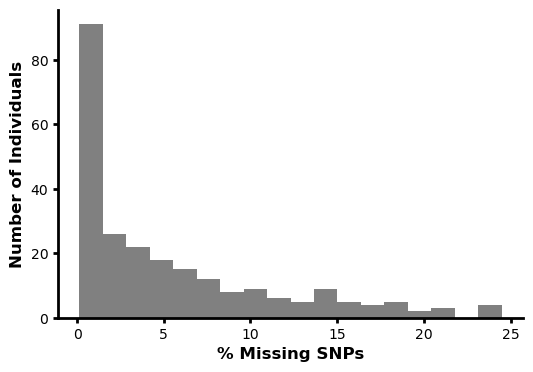

In [19]:
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.hist(df_by_ind['missing_percent'], color = 'gray', bins = 18 )
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_linewidth(2)
ax1.tick_params(axis='both', width=2)
ax1.set_xlabel('% Missing SNPs', fontname='Arial', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Individuals', fontname='Arial', fontweight='bold', fontsize=12)